# Spark Optimization

In [1]:
! java --version


openjdk 17.0.17 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)


## Create Session

In [2]:
from pyspark.sql import SparkSession

In [3]:
spark=SparkSession.builder.master('local[*]')\
      .appName("SparkOptm")\
      .getOrCreate()

In [4]:
spark

## Turn AQE off

In [5]:
spark.conf.set("spark.sql.adaptive.enabled","false")

In [6]:
spark.conf.get("spark.sql.adaptive.enabled")

'false'

## Import dataset

In [7]:
df=spark.read.format("csv")\
.option("header",True)\
.option("inferSchema",True)\
.load('/content/BigMart Sales.csv')

In [8]:
from pyspark.sql.functions import *

In [9]:
df.limit(5).show()

+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|Item_Identifier|Item_Weight|Item_Fat_Content|Item_Visibility|           Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|      Outlet_Type|Item_Outlet_Sales|
+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|          FDA15|        9.3|         Low Fat|    0.016047301|               Dairy|249.8092|           OUT049|                     1999|     Medium|              Tier 1|Supermarket Type1|         3735.138|
|          DRC01|       5.92|         Regular|    0.019278216|         Soft Drinks| 48.2692|           OUT018|                     2009|     Medium|              Tier 3|Superma

## Scanning Optimization

### Get Number of Partitions

In [10]:
df.rdd.getNumPartitions()

1

### Change default partition size to 128 KB

In [11]:
spark.conf.get("spark.sql.files.maxPartitionBytes")

'134217728b'

In [12]:
str(int(134217728)/1024**2)+' MB'

'128.0 MB'

In [13]:
spark.conf.set("spark.sql.files.maxPartitionBytes",131072)

In [14]:
spark.conf.get("spark.sql.files.maxPartitionBytes")

'131072'

#### Reread the data to check no of partitions

In [15]:
df=spark.read.format("csv")\
.option("header",True)\
.option("inferSchema",True)\
.load('/content/BigMart Sales.csv')

In [16]:
df.rdd.getNumPartitions()

7

In [17]:
spark.conf.set("spark.sql.files.maxPartitionBytes",134217728)

In [18]:
spark.conf.get("spark.sql.files.maxPartitionBytes")

'134217728'

### Repartition

In [19]:
df=df.repartition(10)

In [20]:
df.rdd.getNumPartitions()

10

In [21]:
df.withColumn("partion_id",spark_partition_id()).show()

+---------------+-----------+----------------+---------------+------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+----------+
|Item_Identifier|Item_Weight|Item_Fat_Content|Item_Visibility|         Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|      Outlet_Type|Item_Outlet_Sales|partion_id|
+---------------+-----------+----------------+---------------+------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+----------+
|          DRG48|       5.78|         Low Fat|    0.014555066|       Soft Drinks|145.2102|           OUT046|                     1997|      Small|              Tier 1|Supermarket Type1|        3062.0142|         0|
|          FDE24|      14.85|         Low Fat|     0.09344495|      Baking Goods|141.0812|           OUT035|                     2004|      

### Write the partitioned data

In [22]:
! mkdir FileStore

In [23]:
df.write.format('parquet')\
.mode('append')\
.option("path","/content/FileStore")\
.save()

### Read partitioned Data

In [24]:
new_df=spark.read.format("csv")\
.option("header",True)\
.option("inferSchema",True)\
.load('/content/FileStore')

### PartitionBy

In [25]:
df.write.format("parquet")\
.mode("overwrite")\
.partitionBy("Outlet_Location_Type")\
.option("path","/content/FileStore")\
.save()
#less resources will be used when df is filtered say outlet_location_type == Tier 1

## Joins Optimization

In [26]:
spark.conf.get("spark.sql.adaptive.enabled")

'false'

In [27]:
transactions_df=spark.createDataFrame(
    [(1,"US",100),
     (2,"UK",200),
     (3,"NP",300),
     (4,"GER",400)],
    ["id","Country_Code","Amount"]
)
countries_df=spark.createDataFrame(
    [("US","United States of America"),
     ("UK","United Kingdom"),
     ("NP","Nepal"),
     ("GER","Germany")],
      ["Country_Code","Country_Name"]
    )

In [28]:
transactions_df.show()#say fact table

+---+------------+------+
| id|Country_Code|Amount|
+---+------------+------+
|  1|          US|   100|
|  2|          UK|   200|
|  3|          NP|   300|
|  4|         GER|   400|
+---+------------+------+



In [29]:
countries_df.show()#say dim table

+------------+--------------------+
|Country_Code|        Country_Name|
+------------+--------------------+
|          US|United States of ...|
|          UK|      United Kingdom|
|          NP|               Nepal|
|         GER|             Germany|
+------------+--------------------+



In [30]:
df_join=transactions_df.join(countries_df,transactions_df['Country_Code']==countries_df['Country_Code'],'inner')

In [31]:
df_join_optm=transactions_df.join(broadcast(countries_df),transactions_df['Country_Code']==countries_df['Country_Code'],'inner')

### SortMergeJoin Vs BroadCastJoin

In [32]:
df_join.explain(mode='formatted')

== Physical Plan ==
* SortMergeJoin Inner (9)
:- * Sort (4)
:  +- Exchange (3)
:     +- * Filter (2)
:        +- * Scan ExistingRDD (1)
+- * Sort (8)
   +- Exchange (7)
      +- * Filter (6)
         +- * Scan ExistingRDD (5)


(1) Scan ExistingRDD [codegen id : 1]
Output [3]: [id#241L, Country_Code#242, Amount#243L]
Arguments: [id#241L, Country_Code#242, Amount#243L], MapPartitionsRDD[76] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) Filter [codegen id : 1]
Input [3]: [id#241L, Country_Code#242, Amount#243L]
Condition : isnotnull(Country_Code#242)

(3) Exchange
Input [3]: [id#241L, Country_Code#242, Amount#243L]
Arguments: hashpartitioning(Country_Code#242, 200), ENSURE_REQUIREMENTS, [plan_id=209]

(4) Sort [codegen id : 2]
Input [3]: [id#241L, Country_Code#242, Amount#243L]
Arguments: [Country_Code#242 ASC NULLS FIRST], false, 0

(5) Scan ExistingRDD [codegen id : 3]
Output [2]: [Country_Code#244, Country_Name#245]
Arguments: [

In [33]:
df_join_optm.explain(mode='formatted')
#

== Physical Plan ==
* BroadcastHashJoin Inner BuildRight (6)
:- * Filter (2)
:  +- * Scan ExistingRDD (1)
+- BroadcastExchange (5)
   +- * Filter (4)
      +- * Scan ExistingRDD (3)


(1) Scan ExistingRDD [codegen id : 2]
Output [3]: [id#241L, Country_Code#242, Amount#243L]
Arguments: [id#241L, Country_Code#242, Amount#243L], MapPartitionsRDD[76] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) Filter [codegen id : 2]
Input [3]: [id#241L, Country_Code#242, Amount#243L]
Condition : isnotnull(Country_Code#242)

(3) Scan ExistingRDD [codegen id : 1]
Output [2]: [Country_Code#244, Country_Name#245]
Arguments: [Country_Code#244, Country_Name#245], MapPartitionsRDD[81] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(4) Filter [codegen id : 1]
Input [2]: [Country_Code#244, Country_Name#245]
Condition : isnotnull(Country_Code#244)

(5) BroadcastExchange
Input [2]: [Country_Code#244, Countr

#### Explanation

Since optm df uses broadcast join for smaller table it does not require shuffle(exchange) and sort which are performance intensive and hence less steps incomparision to sortmergejoin the default in spark

### Spark Sql hints

In [34]:
transactions_df.createOrReplaceTempView("transactions")
countries_df.createOrReplaceTempView("countries")

In [35]:
sql_df=spark.sql(
    '''
    Select * from
    transactions as t
    Join countries as c
    On t.Country_Code=c.Country_Code
    '''
)

In [36]:
sql_df.explain(mode='formatted')

== Physical Plan ==
* SortMergeJoin Inner (9)
:- * Sort (4)
:  +- Exchange (3)
:     +- * Filter (2)
:        +- * Scan ExistingRDD (1)
+- * Sort (8)
   +- Exchange (7)
      +- * Filter (6)
         +- * Scan ExistingRDD (5)


(1) Scan ExistingRDD [codegen id : 1]
Output [3]: [id#241L, Country_Code#242, Amount#243L]
Arguments: [id#241L, Country_Code#242, Amount#243L], MapPartitionsRDD[76] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) Filter [codegen id : 1]
Input [3]: [id#241L, Country_Code#242, Amount#243L]
Condition : isnotnull(Country_Code#242)

(3) Exchange
Input [3]: [id#241L, Country_Code#242, Amount#243L]
Arguments: hashpartitioning(Country_Code#242, 200), ENSURE_REQUIREMENTS, [plan_id=300]

(4) Sort [codegen id : 2]
Input [3]: [id#241L, Country_Code#242, Amount#243L]
Arguments: [Country_Code#242 ASC NULLS FIRST], false, 0

(5) Scan ExistingRDD [codegen id : 3]
Output [2]: [Country_Code#244, Country_Name#245]
Arguments: [

In [37]:
sql_df_optm=spark.sql(
    '''
    Select *  /* broadcast(countries) */
    from transactions as t
    Join countries as c
    On t.Country_Code=c.Country_Code
    '''
)

In [38]:
sql_df_optm.explain(mode='formatted')

== Physical Plan ==
* SortMergeJoin Inner (9)
:- * Sort (4)
:  +- Exchange (3)
:     +- * Filter (2)
:        +- * Scan ExistingRDD (1)
+- * Sort (8)
   +- Exchange (7)
      +- * Filter (6)
         +- * Scan ExistingRDD (5)


(1) Scan ExistingRDD [codegen id : 1]
Output [3]: [id#241L, Country_Code#242, Amount#243L]
Arguments: [id#241L, Country_Code#242, Amount#243L], MapPartitionsRDD[76] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) Filter [codegen id : 1]
Input [3]: [id#241L, Country_Code#242, Amount#243L]
Condition : isnotnull(Country_Code#242)

(3) Exchange
Input [3]: [id#241L, Country_Code#242, Amount#243L]
Arguments: hashpartitioning(Country_Code#242, 200), ENSURE_REQUIREMENTS, [plan_id=353]

(4) Sort [codegen id : 2]
Input [3]: [id#241L, Country_Code#242, Amount#243L]
Arguments: [Country_Code#242 ASC NULLS FIRST], false, 0

(5) Scan ExistingRDD [codegen id : 3]
Output [2]: [Country_Code#244, Country_Name#245]
Arguments: [

#### Explanation

Sql type hints enclosed within /* */ are advice to spark .It may not always take such advice as shown above

## Caching and Persistance

In [39]:
df=spark.read.format('csv')\
    .option('inferSchema',True)\
    .option('header',True)\
    .load('/content/BigMart Sales.csv')

In [40]:
df2=df.filter(col('Outlet_Type')=='Tier 1').explain(mode='formatted')

== Physical Plan ==
* Filter (2)
+- Scan csv  (1)


(1) Scan csv 
Output [12]: [Item_Identifier#280, Item_Weight#281, Item_Fat_Content#282, Item_Visibility#283, Item_Type#284, Item_MRP#285, Outlet_Identifier#286, Outlet_Establishment_Year#287, Outlet_Size#288, Outlet_Location_Type#289, Outlet_Type#290, Item_Outlet_Sales#291]
Batched: false
Location: InMemoryFileIndex [file:/content/BigMart Sales.csv]
PushedFilters: [IsNotNull(Outlet_Type), EqualTo(Outlet_Type,Tier 1)]
ReadSchema: struct<Item_Identifier:string,Item_Weight:double,Item_Fat_Content:string,Item_Visibility:double,Item_Type:string,Item_MRP:double,Outlet_Identifier:string,Outlet_Establishment_Year:int,Outlet_Size:string,Outlet_Location_Type:string,Outlet_Type:string,Item_Outlet_Sales:double>

(2) Filter [codegen id : 1]
Input [12]: [Item_Identifier#280, Item_Weight#281, Item_Fat_Content#282, Item_Visibility#283, Item_Type#284, Item_MRP#285, Outlet_Identifier#286, Outlet_Establishment_Year#287, Outlet_Size#288, Outlet_Location_

In [41]:
cached_df=spark.read.format('csv')\
    .option('inferSchema',True)\
    .option('header',True)\
    .load('/content/BigMart Sales.csv')\
    .cache()

In [42]:
df2=cached_df.filter(col('Outlet_Type')=='Tier 1').explain(mode='formatted')

== Physical Plan ==
* Filter (4)
+- InMemoryTableScan (1)
      +- InMemoryRelation (2)
            +- Scan csv  (3)


(1) InMemoryTableScan
Output [12]: [Item_Identifier#310, Item_Weight#311, Item_Fat_Content#312, Item_Visibility#313, Item_Type#314, Item_MRP#315, Outlet_Identifier#316, Outlet_Establishment_Year#317, Outlet_Size#318, Outlet_Location_Type#319, Outlet_Type#320, Item_Outlet_Sales#321]
Arguments: [Item_Identifier#310, Item_Weight#311, Item_Fat_Content#312, Item_Visibility#313, Item_Type#314, Item_MRP#315, Outlet_Identifier#316, Outlet_Establishment_Year#317, Outlet_Size#318, Outlet_Location_Type#319, Outlet_Type#320, Item_Outlet_Sales#321], [isnotnull(Outlet_Type#320), (Outlet_Type#320 = Tier 1)]

(2) InMemoryRelation
Arguments: [Item_Identifier#310, Item_Weight#311, Item_Fat_Content#312, Item_Visibility#313, Item_Type#314, Item_MRP#315, Outlet_Identifier#316, Outlet_Establishment_Year#317, Outlet_Size#318, Outlet_Location_Type#319, Outlet_Type#320, Item_Outlet_Sales#321],

### Explanation

Spark does not cache or store the df everytime.it stores in executor memory withtin spark memory pool and then allocates that memory when another action is to be performed.So after caching in explain we see 'InmemoryTableScan"

In [43]:
df.unpersist()

DataFrame[Item_Identifier: string, Item_Weight: double, Item_Fat_Content: string, Item_Visibility: double, Item_Type: string, Item_MRP: double, Outlet_Identifier: string, Outlet_Establishment_Year: int, Outlet_Size: string, Outlet_Location_Type: string, Outlet_Type: string, Item_Outlet_Sales: double]

### Storage Levels

Storage Levels

1.   DISK_ONLY
2.   MEMORY_ONLY
3.   MEMORY_AND_DISK

and much more

In [44]:
from pyspark.storagelevel import StorageLevel

In [45]:
df.persist(StorageLevel.MEMORY_AND_DISK)

DataFrame[Item_Identifier: string, Item_Weight: double, Item_Fat_Content: string, Item_Visibility: double, Item_Type: string, Item_MRP: double, Outlet_Identifier: string, Outlet_Establishment_Year: int, Outlet_Size: string, Outlet_Location_Type: string, Outlet_Type: string, Item_Outlet_Sales: double]

In [46]:
df.unpersist()

DataFrame[Item_Identifier: string, Item_Weight: double, Item_Fat_Content: string, Item_Visibility: double, Item_Type: string, Item_MRP: double, Outlet_Identifier: string, Outlet_Establishment_Year: int, Outlet_Size: string, Outlet_Location_Type: string, Outlet_Type: string, Item_Outlet_Sales: double]

## Dynamic Resource Allocation

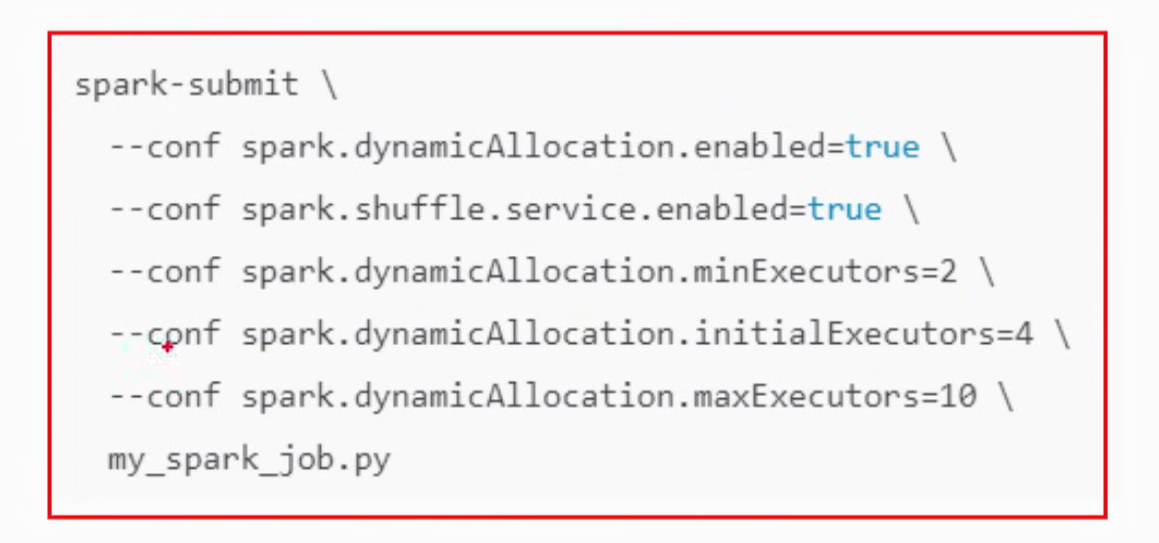

## AQE (Adaptive Query Execution )

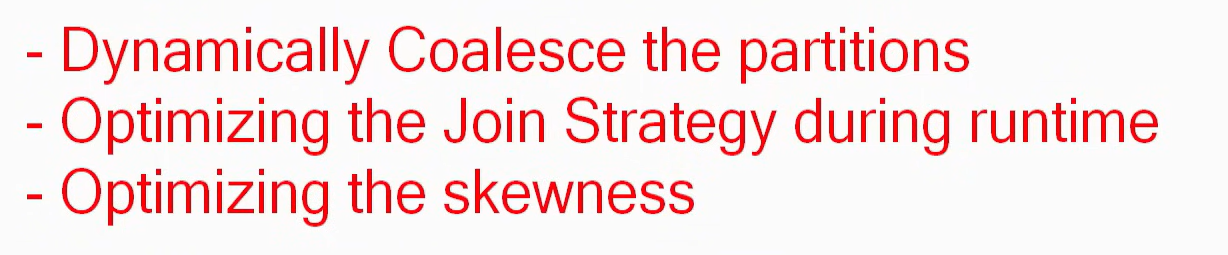

In [47]:
import pandas as pd
df=pd.read_excel('/content/Customer_Shopping_data.xlsx')
df=spark.createDataFrame(df)

In [48]:
spark.conf.set("spark.sql.adaptive.enabled",False)
spark.conf.get("spark.sql.adaptive.enabled")

'false'

In [49]:
df.rdd.getNumPartitions()

2

In [50]:
df.show()

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|   17850.0|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|   17850.0|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|2010-12-01 08:26:00|     7.65|   17850.0|United Kingdom|
|   536365|    21730|GLASS S

In [51]:
df_new=df.groupby('StockCode').count()
df_new.show()

+---------+-----+
|StockCode|count|
+---------+-----+
|    22728|  810|
|    21889|  607|
|   90210B|    7|
|    21259|  296|
|    21894|  135|
|    21452|  200|
|    22121|  141|
|    90022|   21|
|    21249|  119|
|    90143|   22|
|    84881|    8|
|    21248|   68|
|    22254|   61|
|    20868|   46|
|    21331|    8|
|   90197B|   27|
|    22596|  274|
|   90026D|    3|
|   90177A|   10|
|   84899F|    1|
+---------+-----+
only showing top 20 rows


In [52]:
df_new.explain(mode='formatted')

== Physical Plan ==
* HashAggregate (5)
+- Exchange (4)
   +- * HashAggregate (3)
      +- * Project (2)
         +- * Scan ExistingRDD (1)


(1) Scan ExistingRDD [codegen id : 1]
Output [8]: [InvoiceNo#623, StockCode#624, Description#625, Quantity#626L, InvoiceDate#627, UnitPrice#628, CustomerID#629, Country#630]
Arguments: [InvoiceNo#623, StockCode#624, Description#625, Quantity#626L, InvoiceDate#627, UnitPrice#628, CustomerID#629, Country#630], MapPartitionsRDD[110] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) Project [codegen id : 1]
Output [1]: [StockCode#624]
Input [8]: [InvoiceNo#623, StockCode#624, Description#625, Quantity#626L, InvoiceDate#627, UnitPrice#628, CustomerID#629, Country#630]

(3) HashAggregate [codegen id : 1]
Input [1]: [StockCode#624]
Keys [1]: [StockCode#624]
Functions [1]: [partial_count(1)]
Aggregate Attributes [1]: [count#668L]
Results [2]: [StockCode#624, count#669L]

(4) Exchange
Input [2]: [StockC

In [53]:
spark.conf.set("spark.sql.adaptive.enabled",True)


In [54]:
df=pd.read_excel('/content/Customer_Shopping_data.xlsx')
df=spark.createDataFrame(df)

In [55]:
df_new_aqe=df.groupby('StockCode').count()
df_new_aqe.show()

+---------+-----+
|StockCode|count|
+---------+-----+
|    22728|  810|
|    21889|  607|
|   90210B|    7|
|    21259|  296|
|    21894|  135|
|    21452|  200|
|    22121|  141|
|    90022|   21|
|    21249|  119|
|    90143|   22|
|    84881|    8|
|    21248|   68|
|    22254|   61|
|    20868|   46|
|    21331|    8|
|   90197B|   27|
|    22596|  274|
|   90026D|    3|
|   90177A|   10|
|   84899F|    1|
+---------+-----+
only showing top 20 rows


In [56]:
df_new_aqe.explain(mode='formatted')

== Physical Plan ==
AdaptiveSparkPlan (6)
+- HashAggregate (5)
   +- Exchange (4)
      +- HashAggregate (3)
         +- Project (2)
            +- Scan ExistingRDD (1)


(1) Scan ExistingRDD
Output [8]: [InvoiceNo#675, StockCode#676, Description#677, Quantity#678L, InvoiceDate#679, UnitPrice#680, CustomerID#681, Country#682]
Arguments: [InvoiceNo#675, StockCode#676, Description#677, Quantity#678L, InvoiceDate#679, UnitPrice#680, CustomerID#681, Country#682], MapPartitionsRDD[126] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) Project
Output [1]: [StockCode#676]
Input [8]: [InvoiceNo#675, StockCode#676, Description#677, Quantity#678L, InvoiceDate#679, UnitPrice#680, CustomerID#681, Country#682]

(3) HashAggregate
Input [1]: [StockCode#676]
Keys [1]: [StockCode#676]
Functions [1]: [partial_count(1)]
Aggregate Attributes [1]: [count#695L]
Results [2]: [StockCode#676, count#696L]

(4) Exchange
Input [2]: [StockCode#676, count#696L]
A

## Dynamic Partition Pruning

### turn off aqe dpp and autobroadcast

In [82]:
spark.conf.set('spark.sql.adaptive.enabled',False)
spark.conf.set('spark.sql.optimizer.dynamicPartitionPruning.enabled',False)
spark.conf.set('sparl.sql.autoBroadcastJoinThreshold',-1)


In [83]:
df=spark.read.format("csv")\
.option("header",True)\
.option("inferSchema",True)\
.load('/content/BigMart Sales.csv')

In [84]:
df_lim=df.limit(8)

In [85]:
df_lim.show()

+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|Item_Identifier|Item_Weight|Item_Fat_Content|Item_Visibility|           Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|      Outlet_Type|Item_Outlet_Sales|
+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|          FDA15|        9.3|         Low Fat|    0.016047301|               Dairy|249.8092|           OUT049|                     1999|     Medium|              Tier 1|Supermarket Type1|         3735.138|
|          DRC01|       5.92|         Regular|    0.019278216|         Soft Drinks| 48.2692|           OUT018|                     2009|     Medium|              Tier 3|Superma

### Partitioned Data

In [86]:
df_lim.write.format('parquet')\
.mode('Overwrite')\
.partitionBy('Item_Identifier')\
.option('path','/content/FileStore/Partitioned')\
.save()

### Non partitioned

In [87]:
df_lim.write.format('parquet')\
.mode('Overwrite')\
.partitionBy('Item_Identifier')\
.option('path','/content/FileStore/NonPartitioned')\
.save()

In [88]:
df1=spark.read.format('parquet')\
.load('/content/FileStore/Partitioned')
df2=spark.read.format('parquet')\
.load('/content/FileStore/NonPartitioned')


### JOin

In [92]:
df1_join=df1.join(df2.filter(col('Item_Identifier')=='FDX07'),df1['Item_Identifier']==df2['Item_Identifier'],'inner')

In [93]:
df1_join.show()

+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-------------+-----------------+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-------------+-----------------+---------------+
|Item_Weight|Item_Fat_Content|Item_Visibility|           Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|  Outlet_Type|Item_Outlet_Sales|Item_Identifier|Item_Weight|Item_Fat_Content|Item_Visibility|           Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|  Outlet_Type|Item_Outlet_Sales|Item_Identifier|
+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-------------+-----------------+-----------

In [94]:
df1_join.explain(mode='formatted')

== Physical Plan ==
* BroadcastHashJoin Inner BuildRight (6)
:- * ColumnarToRow (2)
:  +- Scan parquet  (1)
+- BroadcastExchange (5)
   +- * ColumnarToRow (4)
      +- Scan parquet  (3)


(1) Scan parquet 
Output [12]: [Item_Weight#1126, Item_Fat_Content#1127, Item_Visibility#1128, Item_Type#1129, Item_MRP#1130, Outlet_Identifier#1131, Outlet_Establishment_Year#1132, Outlet_Size#1133, Outlet_Location_Type#1134, Outlet_Type#1135, Item_Outlet_Sales#1136, Item_Identifier#1137]
Batched: true
Location: InMemoryFileIndex [file:/content/FileStore/Partitioned]
PartitionFilters: [(Item_Identifier#1137 = FDX07), isnotnull(Item_Identifier#1137)]
ReadSchema: struct<Item_Weight:double,Item_Fat_Content:string,Item_Visibility:double,Item_Type:string,Item_MRP:double,Outlet_Identifier:string,Outlet_Establishment_Year:int,Outlet_Size:string,Outlet_Location_Type:string,Outlet_Type:string,Item_Outlet_Sales:double>

(2) ColumnarToRow [codegen id : 2]
Input [12]: [Item_Weight#1126, Item_Fat_Content#1127, It

Here it reads all the files and does not invoke DPP so reads partioned data=no of partioned data and non partitioned data =1 total=2+

### Invoke DPP

In [96]:
spark.conf.set('spark.sql.adaptive.enabled',True)
spark.conf.set('spark.sql.optimizer.dynamicPartitionPruning.enabled',True)
spark.conf.set('sparl.sql.autoBroadcastJoinThreshold',5*1034*1024)

In [97]:
df1_join=df1.join(df2.filter(col('Item_Identifier')=='FDX07'),df1['Item_Identifier']==df2['Item_Identifier'],'inner')

In [98]:
df1_join.explain(mode='formatted')

== Physical Plan ==
AdaptiveSparkPlan (5)
+- BroadcastHashJoin Inner BuildRight (4)
   :- Scan parquet  (1)
   +- BroadcastExchange (3)
      +- Scan parquet  (2)


(1) Scan parquet 
Output [12]: [Item_Weight#1126, Item_Fat_Content#1127, Item_Visibility#1128, Item_Type#1129, Item_MRP#1130, Outlet_Identifier#1131, Outlet_Establishment_Year#1132, Outlet_Size#1133, Outlet_Location_Type#1134, Outlet_Type#1135, Item_Outlet_Sales#1136, Item_Identifier#1137]
Batched: true
Location: InMemoryFileIndex [file:/content/FileStore/Partitioned]
PartitionFilters: [(Item_Identifier#1137 = FDX07), isnotnull(Item_Identifier#1137)]
ReadSchema: struct<Item_Weight:double,Item_Fat_Content:string,Item_Visibility:double,Item_Type:string,Item_MRP:double,Outlet_Identifier:string,Outlet_Establishment_Year:int,Outlet_Size:string,Outlet_Location_Type:string,Outlet_Type:string,Item_Outlet_Sales:double>

(2) Scan parquet 
Output [12]: [Item_Weight#1138, Item_Fat_Content#1139, Item_Visibility#1140, Item_Type#1141, Ite

DPP says it will broadcast the filter ccondition on the joining df aswell during runtime.For the above example it will read/scan the non partioned data (no of file =1) and then broadcast the filter condition ie scan for only 'FDX07' so will read the partitioned data where item_identifier is FDX07 (no of files=1) total =2 .DPP is invoked only when the partioned key == filter_key

## Broadcast variable

In [102]:
product_df=spark.createDataFrame(
    [('1',),('2',),('3',)],['product_id']
)

In [103]:
product_df.show()

+----------+
|product_id|
+----------+
|         1|
|         2|
|         3|
+----------+



In [105]:
product_dict={
    '1':'product_1',
    '2':'product_2',
    '3':'product_3'
}

### broadcast tthe dictionary variable to sparkcontext

In [106]:
broad_var=spark.sparkContext.broadcast(product_dict)

In [107]:
def my_map(x):
  return broad_var.value.get(x)

In [108]:
my_udf=udf(my_map)

In [110]:
product_df=product_df.withColumn('product_name',my_udf("product_id"))

In [111]:
product_df.show()

+----------+------------+
|product_id|product_name|
+----------+------------+
|         1|   product_1|
|         2|   product_2|
|         3|   product_3|
+----------+------------+



## Salting - OOM

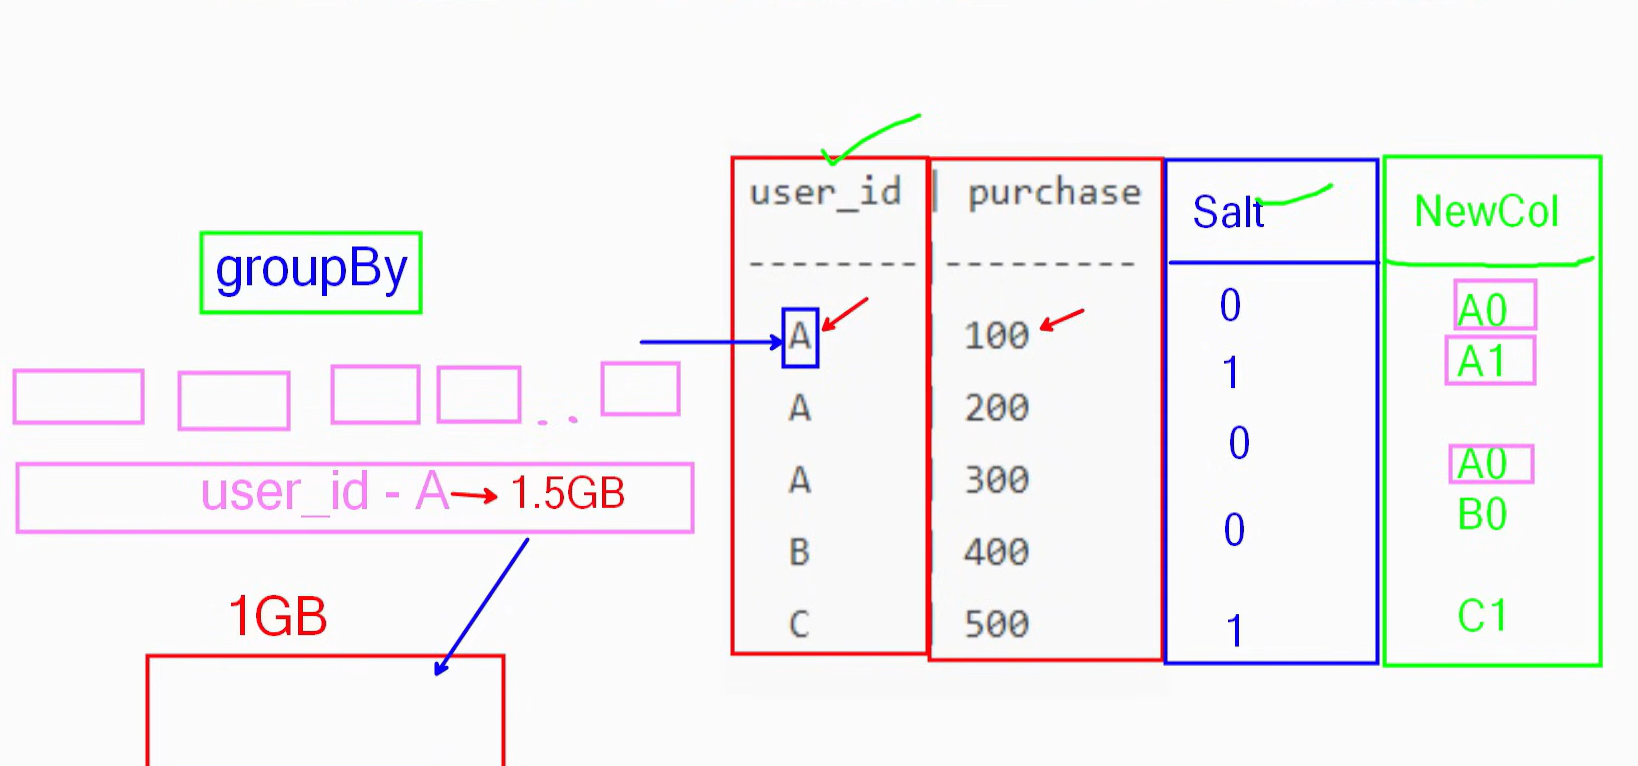

In [112]:
purchase_df=spark.createDataFrame(
    [('A',100),('A',300),('B',500),('C',600),('A',200)],['user_id','amount']
)

In [113]:
purchase_df.show()

+-------+------+
|user_id|amount|
+-------+------+
|      A|   100|
|      A|   300|
|      B|   500|
|      C|   600|
|      A|   200|
+-------+------+



### add salt column

In [114]:
purchase_df=purchase_df.withColumn("Salt",floor(rand()*3))

In [115]:
purchase_df.show()

+-------+------+----+
|user_id|amount|Salt|
+-------+------+----+
|      A|   100|   2|
|      A|   300|   1|
|      B|   500|   0|
|      C|   600|   1|
|      A|   200|   2|
+-------+------+----+



### concat column on original grouby userid and salt to create new grouby col

In [117]:
purchase_df=purchase_df.withColumn('Salt_uid',concat(col("user_id"),lit("_"),col("Salt")))

In [118]:
purchase_df.show()

+-------+------+----+--------+
|user_id|amount|Salt|Salt_uid|
+-------+------+----+--------+
|      A|   100|   2|     A_2|
|      A|   300|   1|     A_1|
|      B|   500|   0|     B_0|
|      C|   600|   1|     C_1|
|      A|   200|   2|     A_2|
+-------+------+----+--------+



In [121]:
salt_groupby=purchase_df.groupBy("Salt_uid").agg(sum("amount").alias("Total Purchase"))
salt_groupby.show()

+--------+--------------+
|Salt_uid|Total Purchase|
+--------+--------------+
|     A_1|           300|
|     A_2|           300|
|     C_1|           600|
|     B_0|           500|
+--------+--------------+

